# Pipeline de Data Mining — Segmentation Stratégique (Modèle RFM)

## Phase 1 : Acquisition et Ingestion (Ingestion Big Data)

### Q1 & Q2: Chargement CSV et Conversion Parquet
Nous allons charger le fichier .csv initial, le sauvegarder au format .parquet et comparer les temps de lecture.

In [1]:
import pandas as pd
import time
import os

csv_path = 'Online_Retail.csv'
parquet_path = 'Online_Retail.parquet'

# Temps de lecture CSV
start_time = time.time()
df_csv = pd.read_csv(csv_path, encoding='ISO-8859-1')
csv_read_time = time.time() - start_time
print(f"Temps de lecture CSV: {csv_read_time:.4f} secondes")

# Sauvegarde en Parquet
df_csv.to_parquet(parquet_path)

# Temps de lecture Parquet
start_time = time.time()
df_parquet = pd.read_parquet(parquet_path)
parquet_read_time = time.time() - start_time
print(f"Temps de lecture Parquet: {parquet_read_time:.4f} secondes")

print(f"Le format Parquet est {(csv_read_time / parquet_read_time):.2f}x plus rapide que le CSV.")


Temps de lecture CSV: 0.6194 secondes


Temps de lecture Parquet: 0.0572 secondes
Le format Parquet est 10.83x plus rapide que le CSV.


**Pourquoi le format Parquet est-il privilégié?**

Le format Parquet est un stockage colonnaire. Il permet une compression plus efficace, des temps de lecture réduits (car on ne lit que les colonnes nécessaires) et une meilleure intégration avec les outils de Big Data comme Spark.

## Phase 2 : Data Cleaning (Le défi du monde réel)

### Q3: Analyse des manquants
Identifiez le pourcentage de valeurs nulles pour chaque colonne et supprimez les lignes sans CustomerID.

In [2]:
# Pourcentage de valeurs nulles
null_counts = df_parquet.isnull().mean() * 100
print("Pourcentage de valeurs nulles par colonne :")
print(null_counts)

# Suppression des lignes sans CustomerID
df_cleaned = df_parquet.dropna(subset=['CustomerID'])
print(f"\nNombre de lignes après suppression des CustomerID nuls: {len(df_cleaned)}")


Pourcentage de valeurs nulles par colonne :
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

Nombre de lignes après suppression des CustomerID nuls: 406829


### Q4: Nettoyage métier
Éliminez les transactions dont la quantité est négative (annulations) et supprimez les prix unitaires aberrants.

In [3]:
# Filtrage des quantités positives et prix unitaires > 0
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['UnitPrice'] > 0)]
print(f"Nombre de lignes après nettoyage métier: {len(df_cleaned)}")


Nombre de lignes après nettoyage métier: 397884


### Q5: Ingénierie de base
Créez une variable MontantTotal = Quantity × UnitPrice.

In [4]:
df_cleaned['MontantTotal'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']
df_cleaned.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,MontantTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Phase 3 : Feature Engineering (Transformation RFM)

### Q6: Agrégation RFM
Calcul de la Récence, Fréquence et Montant par client.

In [5]:
import datetime as dt

# Assurer que InvoiceDate est au format datetime
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# Date de référence pour la récence (Max Date + 1 jour)
reference_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)

df_rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'MontantTotal': 'sum'
})

df_rfm.columns = ['Recence', 'Frequence', 'Montant']
df_rfm.head()


,Recence,Frequence,Montant
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### Q7: Analyse de la distribution
Traçons l'histogramme de la variable Montant.

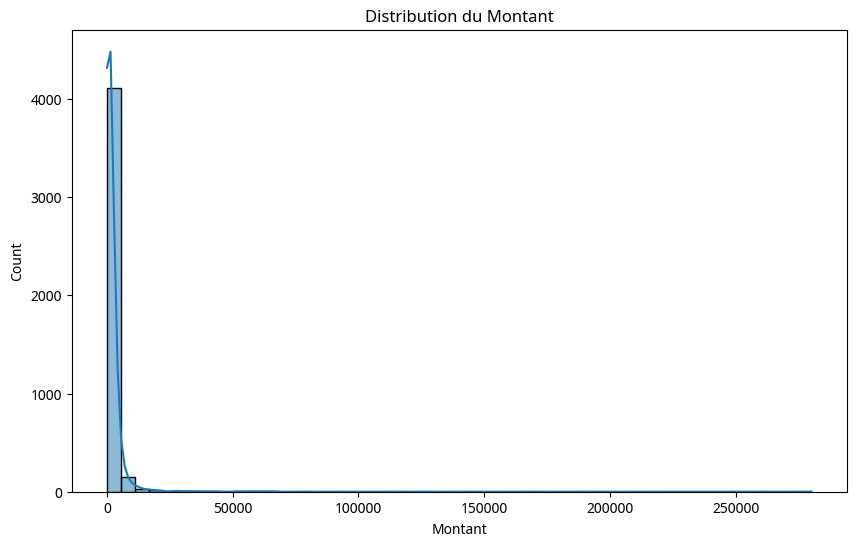

On observe une forte asymétrie à droite (skewness), typique des données de consommation.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_rfm['Montant'], bins=50, kde=True)
plt.title('Distribution du Montant')
plt.show()

print("On observe une forte asymétrie à droite (skewness), typique des données de consommation.")


### Q8: Transformation Log
Application d'une transformation logarithmique pour réduire l'impact des valeurs extrêmes.

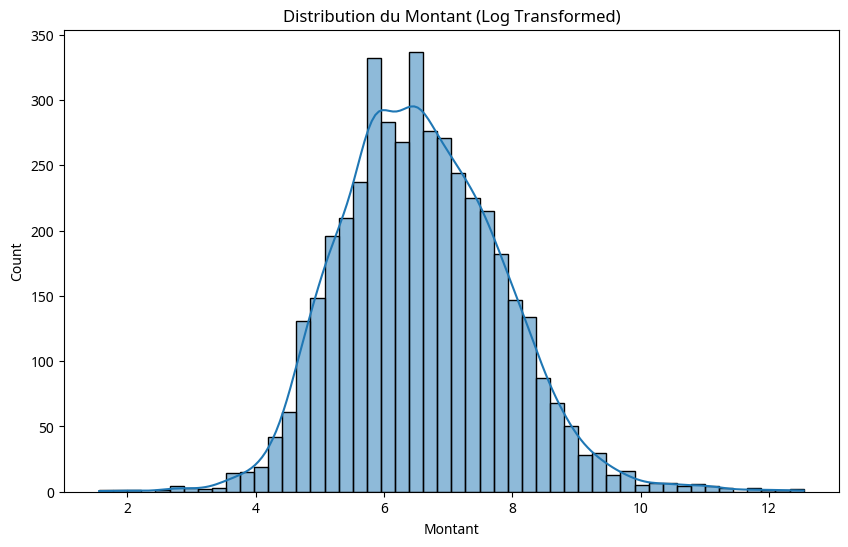

In [7]:
import numpy as np

df_rfm_log = df_rfm.copy()
df_rfm_log['Recence'] = np.log1p(df_rfm['Recence'])
df_rfm_log['Frequence'] = np.log1p(df_rfm['Frequence'])
df_rfm_log['Montant'] = np.log1p(df_rfm['Montant'])

plt.figure(figsize=(10, 6))
sns.histplot(df_rfm_log['Montant'], bins=50, kde=True)
plt.title('Distribution du Montant (Log Transformed)')
plt.show()


### Q9: Standardisation
Utilisation de StandardScaler pour normaliser les variables.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm_log)

df_rfm_scaled = pd.DataFrame(rfm_scaled, index=df_rfm.index, columns=df_rfm.columns)
df_rfm_scaled.head()


,Recence,Frequence,Montant
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962


**Pourquoi cette étape est mathématiquement obligatoire pour le K-Means?**

Le K-Means utilise la distance euclidienne pour regrouper les points. Si les variables ont des échelles différentes (ex: Récence en jours vs Montant en milliers), la variable avec la plus grande échelle dominera le calcul de la distance. La standardisation remet toutes les variables sur une échelle comparable (moyenne 0, écart-type 1).

## Phase 4 : Clustering et Optimisation

### Q10: Recherche du K optimal (Méthode du coude)

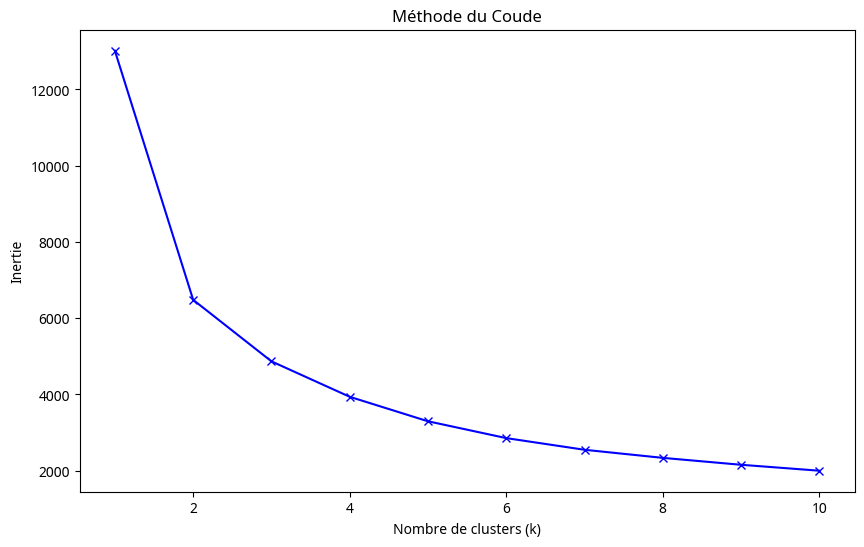

In [9]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude')
plt.show()


### Q11: Validation (Silhouette Score)

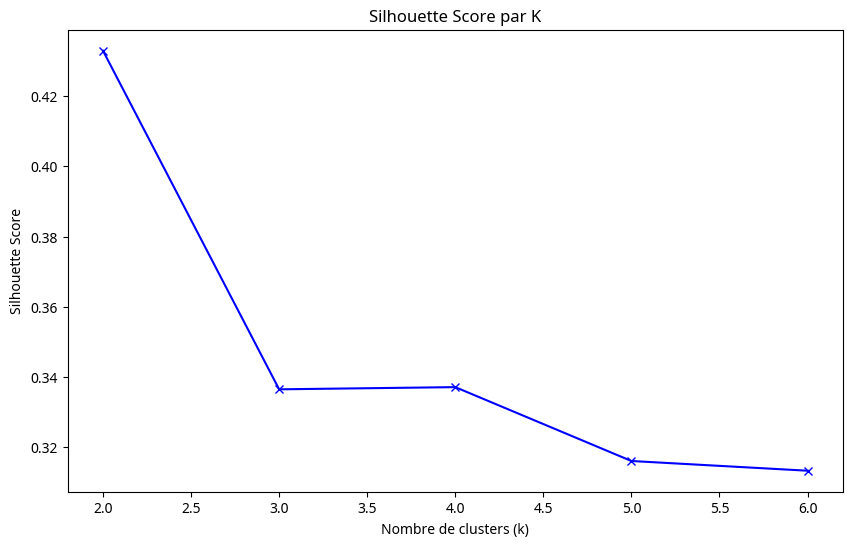

In [10]:
from sklearn.metrics import silhouette_score

silhouette_avg = []
K_range_sil = range(2, 7) # Calculer pour quelques valeurs de K

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_rfm_scaled)
    silhouette_avg.append(silhouette_score(df_rfm_scaled, cluster_labels))

plt.figure(figsize=(10, 6))
plt.plot(K_range_sil, silhouette_avg, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score par K')
plt.show()


### Q12: Application du K-Means final

In [11]:
# Supposons que K=3 ou 4 soit optimal d'après les graphes
k_optimal = 3 
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans.fit_predict(df_rfm_scaled)
df_rfm.head()


,Recence,Frequence,Montant,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,2
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,1


## Phase 5 : Découverte de Connaissances (Data Storytelling)

### Q13: Analyse des moyennes par cluster

In [12]:
cluster_analysis = df_rfm.groupby('Cluster').agg({
    'Recence': 'mean',
    'Frequence': 'mean',
    'Montant': ['mean', 'count']
}).round(2)

print(cluster_analysis)


        Recence Frequence  Montant      
           mean      mean     mean count
Cluster                                 
0         17.06     13.34  7905.44   770
1        167.36      1.35   362.54  1872
2         44.21      3.38  1265.06  1696


### Q14: Profilage des segments

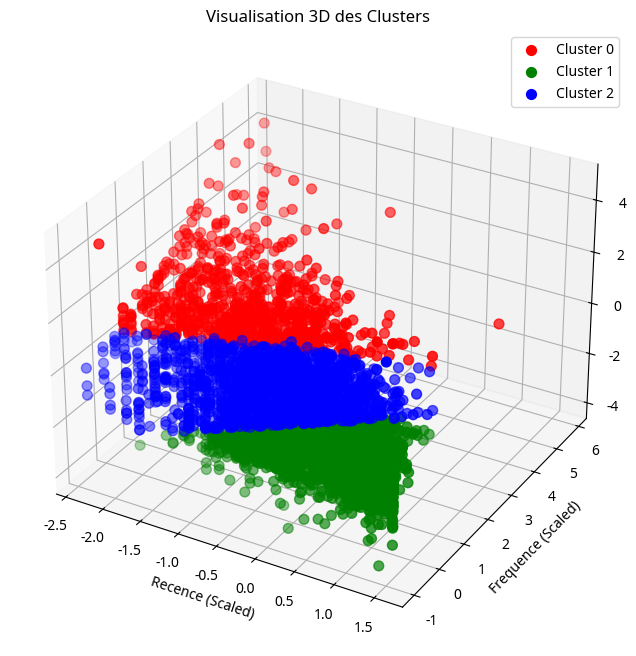

In [13]:
# Visualisation 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'y']
for i in range(k_optimal):
    mask = (df_rfm['Cluster'] == i).values
    ax.scatter(df_rfm_scaled.iloc[mask, 0], 
               df_rfm_scaled.iloc[mask, 1], 
               df_rfm_scaled.iloc[mask, 2], 
               c=colors[i], label=f'Cluster {i}', s=50)

ax.set_xlabel('Recence (Scaled)')
ax.set_ylabel('Frequence (Scaled)')
ax.set_zlabel('Montant (Scaled)')
plt.legend()
plt.title('Visualisation 3D des Clusters')
plt.show()


### Q15: Action Commerciale

**Stratégies suggérées :**

1. **Champions (Haute Fréquence, Haut Montant, Faible Récence) :** Programme de fidélité VIP, accès anticipé aux nouveaux produits.
2. **Clients à Risque (Haute Récence, Faible Fréquence/Montant) :** Campagnes de réactivation, remises spéciales 'On vous regrette'.
3. **Nouveaux Clients / Potentiels :** Newsletters informatives, offres de bienvenue pour un deuxième achat.